In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -U git+https://github.com/qubvel/classification_models.git

  Cloning https://github.com/qubvel/classification_models.git to /tmp/pip-req-build-51et2q07
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/classification_models.git /tmp/pip-req-build-51et2q07
  Resolved https://github.com/qubvel/classification_models.git to commit a0f006e05485a34ccf871c421279864b0ccd220b
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.8 MB/s eta 0:00:00
  Created wheel for image_classifiers: filename=image_classifiers-1.0.0-py3-none-any.whl size=20029 sha256=a0893b057de1c2447be10a952d2c340bcf5bdd24689adb05672f228c359b17bf
  Stored in directory: /tmp/pip-ephem-wheel-cache-nwjhlcqm/wheels/14/43/ed/2d68b197c5260e7fe6b7d0fab20b997b6d365f6f5732316952
Successfully built image_classifiers


In [2]:
import tensorflow as tf
from classification_models.tfkeras import Classifiers
from tensorflow.keras.layers import (Input, Conv2D, GlobalAveragePooling2D,
                                     Dense, Multiply, Add, Concatenate, Reshape,
                                     Activation, Lambda)
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from itertools import cycle
from sklearn.preprocessing import label_binarize

2025-04-28 16:55:34.051932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745859334.374246      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745859334.453990      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE


In [4]:
MAIN_DIR = '/kaggle/input/cassava-dataset'
TRAIN_DIR = MAIN_DIR + '/CASSAVA'
TEST_DIR = TRAIN_DIR

In [5]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 21397 files belonging to 5 classes.
Using 17118 files for training.


I0000 00:00:1745859456.617802      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745859456.618560      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)



Found 21397 files belonging to 5 classes.
Using 4279 files for validation.


In [7]:
class_names = train_ds_raw.class_names
NUM_CLASSES = len(class_names)

# Cache and prefetch
train_ds = train_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)


In [8]:
ResNet34, preprocess_input = Classifiers.get('resnet34')
preprocess_layer = tf.keras.layers.Lambda(lambda x: preprocess_input(x))

In [9]:
def Cosin_similarity(tensors):
    a, b = tensors
    dot_product = tf.reduce_sum(a * b, axis=-1, keepdims=True)
    norm_a = tf.norm(a, axis=-1, keepdims=True)
    norm_b = tf.norm(b, axis=-1, keepdims=True)
    return dot_product / (norm_a * norm_b + tf.keras.backend.epsilon())

def Bund(inputs):
    alpha_1, alpha_2 = inputs
    total = alpha_1 + alpha_2 + tf.keras.backend.epsilon()
    alpha_l = alpha_1 / total
    alpha_g = alpha_2 / total
    return alpha_l, alpha_g


In [10]:
def eca_module(input_tensor, gamma=2):
    channels = input_tensor.shape[-1]
    squeeze = GlobalAveragePooling2D()(input_tensor)
    excitation = Dense(units=channels // gamma)(squeeze)
    excitation = Activation('relu')(excitation)
    excitation = Dense(units=channels)(excitation)
    excitation = Activation('sigmoid')(excitation)
    excitation = Reshape((1, 1, channels))(excitation)
    scale = Multiply()([input_tensor, excitation])
    output = Add()([scale, input_tensor])
    return output


In [11]:
def res_csa_module(input_tensor, reduction_ratio=16):
    channels = input_tensor.shape[-1]
    conv1 = Conv2D(filters=channels // reduction_ratio, kernel_size=(1,1), padding='same', activation='relu')(input_tensor)
    conv2 = Conv2D(filters=channels // reduction_ratio, kernel_size=(1,1), padding='same', activation='relu')(conv1)
    conv3 = Conv2D(filters=channels, kernel_size=(1,1), padding='same', activation='relu')(conv2)
    attention_map = Conv2D(filters=1, kernel_size=(1,1), padding='same', activation='sigmoid')(conv3)
    attention = Multiply()([attention_map, input_tensor])
    output = Add()([attention, input_tensor])
    return output


In [12]:
def build_model(input_shape, num_classes):
    input_tensor = Input(shape=input_shape)
    x = preprocess_layer(input_tensor)
    backbone_output = ResNet34(input_shape=input_shape, weights='imagenet', include_top=False)(x)
    
    eca_out = eca_module(backbone_output)
    res_csa_out = res_csa_module(backbone_output)
    
    x = Add()([backbone_output, eca_out, res_csa_out])
    
    x_l = GlobalAveragePooling2D()(eca_out)
    x_g = GlobalAveragePooling2D()(res_csa_out)
    x_c = GlobalAveragePooling2D()(x)
    
    x_l = Dense(384, activation='relu')(x_l)
    x_g = Dense(384, activation='relu')(x_g)
    x_c = Dense(384, activation='relu')(x_c)
    
    share = Dense(768, activation='relu')
    x_l = share(x_l)
    x_g = share(x_g)
    x_c = share(x_c)
    
    x_l = Dense(768, activation='relu')(x_l)
    x_g = Dense(768, activation='relu')(x_g)
    x_c = Dense(768, activation='relu')(x_c)
    
    x_l = Dense(num_classes, activation='softmax')(x_l)
    x_g = Dense(num_classes, activation='softmax')(x_g)
    x_c = Dense(num_classes, activation='softmax')(x_c)
    
    alpha_1 = Lambda(Cosin_similarity)([x_l, x_c])
    alpha_2 = Lambda(Cosin_similarity)([x_g, x_c])
    alpha_l, alpha_g = Lambda(Bund)([alpha_1, alpha_2])
    
    out_l = Multiply()([alpha_l, x_l])
    out_g = Multiply()([alpha_g, x_g])
    
    out = Concatenate()([out_l, out_g])
    out = Dense(64, activation='relu')(out)
    out = Dense(num_classes, activation='softmax')(out)
    
    model = Model(inputs=input_tensor, outputs=out)
    return model

In [13]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True
)

In [14]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model = build_model(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 128, 128, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ (None, 4, 4, 512)      │     21,302,473 │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 512)            │              0 │ functional[0][0]       │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        131,328 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 256)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 4, 4, 32)       │         16,416 │ functional[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 512)            │        131,584 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 4, 4, 32)       │          1,056 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 512)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 4, 4, 512)      │         16,896 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 512)      │              0 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 4, 4, 1)        │            513 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 4, 4, 512)      │              0 │ functional[0][0],      │
│                           │                        │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 4, 4, 512)      │              0 │ conv2d_3[0][0],        │
│                           │                        │                │ functional[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_16 (Add)              │ (None, 4, 4, 512)      │              0 │ multiply[0][0],        │
│                           │                        │                │ functional[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_17 (Add)              │ (None, 4, 4, 512)      │              0 │ multiply_1[0][0],      │
│                           │                        │                │ functional[0][0]       │
├──────────────────────

 Total params: 24,271,262 (92.59 MB)

 Trainable params: 24,255,896 (92.53 MB)

 Non-trainable params: 15,366 (60.02 KB)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Epoch 1/100


I0000 00:00:1745859582.063492     169 service.cc:148] XLA service 0x7a2c28002c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745859582.064537     169 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745859582.064557     169 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745859585.324117     169 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/535 ━━━━━━━━━━━━━━━━━━━━ 7:28:33 50s/step - accuracy: 0.0625 - loss: 1.6416

I0000 00:00:1745859599.827703     169 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


535/535 ━━━━━━━━━━━━━━━━━━━━ 140s 167ms/step - accuracy: 0.5367 - loss: 1.4443 - val_accuracy: 0.6495 - val_loss: 1.1662
Epoch 2/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 60s 112ms/step - accuracy: 0.6451 - loss: 1.1187 - val_accuracy: 0.6569 - val_loss: 0.9861
Epoch 3/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 59s 111ms/step - accuracy: 0.6681 - loss: 0.9478 - val_accuracy: 0.6459 - val_loss: 0.9821
Epoch 4/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 59s 111ms/step - accuracy: 0.6847 - loss: 0.8456 - val_accuracy: 0.6731 - val_loss: 0.8634
Epoch 5/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 60s 111ms/step - accuracy: 0.7134 - loss: 0.7700 - val_accuracy: 0.6618 - val_loss: 0.8620
Epoch 6/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 59s 111ms/step - accuracy: 0.7353 - loss: 0.7069 - val_accuracy: 0.6787 - val_loss: 0.8439
Epoch 7/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 60s 111ms/step - accuracy: 0.7576 - loss: 0.6367 - val_accuracy: 0.5415 - val_loss: 1.1284
Epoch 8/100
535/535 ━━━━━━━━━━━━━━━━━━━━ 60s 111ms/step - accuracy: 0.7632 - loss: 0.60

In [16]:
if TEST_DIR:
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        label_mode='categorical'
    )
    test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)
    
    # Evaluation
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_true, axis=1)
    
    print(classification_report(y_true_classes, y_pred, target_names=class_names))


Found 21397 files belonging to 5 classes.
669/669 ━━━━━━━━━━━━━━━━━━━━ 31s 46ms/step - accuracy: 0.9060 - loss: 0.4894
Test Loss: 0.2838
Test Accuracy: 0.9449
669/669 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1087
           1       0.92      0.88      0.90      2189
           2       0.92      0.85      0.89      2386
           3       0.90      0.90      0.90      2577
           4       0.97      0.99      0.98     13158

    accuracy                           0.94     21397
   macro avg       0.92      0.90      0.91     21397
weighted avg       0.94      0.94      0.94     21397



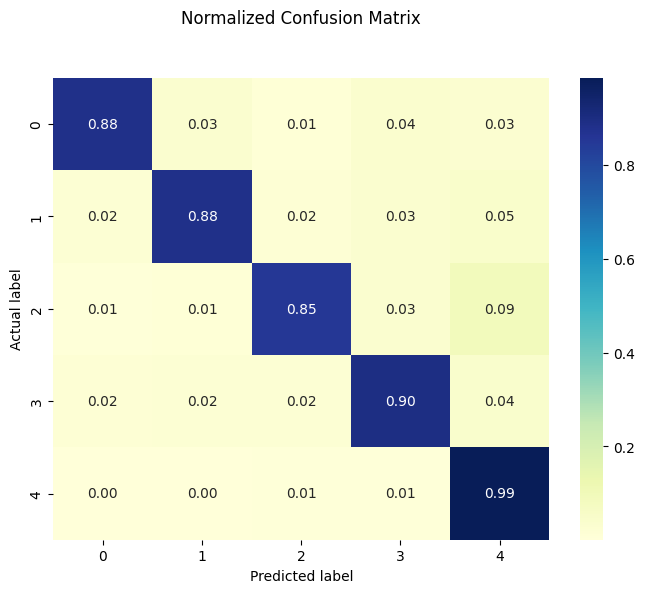

In [18]:
cm = confusion_matrix(y_true_classes, y_pred)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] 

plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(cm), annot=True, fmt='.2f', cmap="YlGnBu",
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()


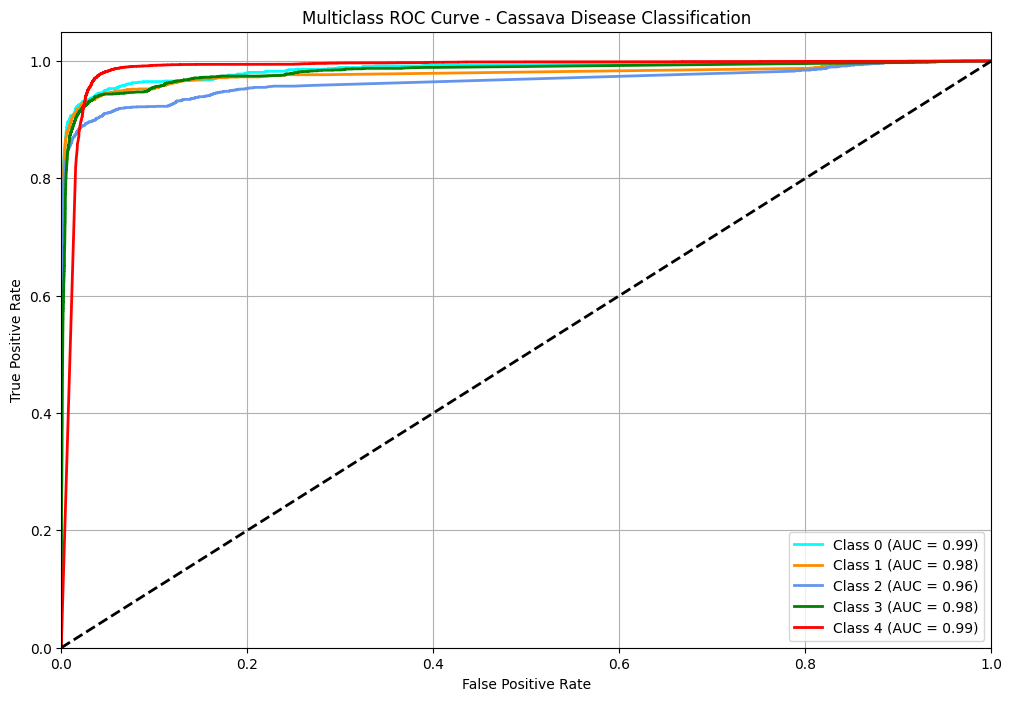

In [20]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true_classes, classes=list(range(NUM_CLASSES)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive'])

for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Cassava Disease Classification')
plt.legend(loc="lower right")
plt.grid()
plt.show()